In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyBioInfo.IO.File import BedFile, BamFile

# Tracks

In [2]:
transcripts = {t.name: t for t in BedFile("/home/chenzonggui/species/homo_sapiens/GRCh38.p13/gencode.v39.annotation.transcripts.bed.gz")}
anno = pd.read_csv("/home/chenzonggui/species/homo_sapiens/GRCh38.p13/gencode.v39.transcript_info.csv", index_col=0)
for tid, tname, gname in zip(anno.index, anno["TranscriptName"], anno["GeneName"]):
    t = transcripts[tid]
    t.transcript_name = tname
    t.gene_name = gname

In [5]:
def get_coverages(path, chrom, start, end):
    covs = np.zeros(end - start)
    with BamFile(path, random=True) as f:
        for item in f.fetch(chrom, start, end):
            if item.segment.is_duplicate:
                continue
            for block_start, block_end in item.blocks:
                for idx in range(block_start - start, block_end - start):
                    if 0 <= idx < len(covs):
                        covs[idx] += 1  
    return covs

def plot_tracks(transcripts, start, end, step, junctions=None, figsize=(6, 3), outfile=None):
    chrom = transcripts[0].chrom
    strand = transcripts[0].strand
    
    bams = [
        "../3_pseudobulk/results/bams/K562.s4U_0uM_3h.bam",
        "../../3_RNAseq_ActD/results/2_mapping/4_rmdup/20221128_K562_Actd_0h_rep1.human.bam"]
    covs_list = [get_coverages(path, chrom, start, end) for path in bams]
    
    if False:
        for covs in covs_list:
            plt.figure(figsize=(8, 2))
            xs = np.arange(start, end)
            plt.plot(xs, covs)
            plt.tight_layout()
            plt.show()
            plt.close()
        
    nrow = 4
    fig, axs = plt.subplots(nrow, 1, figsize=figsize, sharex=True, gridspec_kw={"hspace": 0})

    labels = ["NanoNASC-seq", "RNA-seq"]
    colors = ["C4", "C7"]
    for i, covs in enumerate(covs_list[:2]):
        ax = axs[i]
        plt.sca(ax)
        xs = np.arange(start, end)
        ys = covs
        plt.fill_between(xs, ys, color=colors[i])
        plt.ylim(0, max(ys) * 1.2)
        plt.ylabel(labels[min(i, 1)], rotation=0, va="center", ha="right")
        plt.yticks([])

    ax = axs[nrow - 2]
    plt.sca(ax)
    plt.ylabel("Splicing junction", rotation=0, va="center", ha="right")
    plt.yticks([])
    plt.ylim(-0.6, 0)
    
    # plot splicing junction
    def get_ellipse_xy(s, e, b):
        center = (s + e) / 2
        a = (e - s) / 2
        a2 = a**2
        b2 = b**2
        c2 = a2 - b2
        xs = np.arange(s, e, 0.1)
        xs1 = xs - center
        x2 = xs1**2
        ys = (1 - x2 / a2) * b2
        ys = -np.power((1 - x2 / a2) * b2, 0.5)
        return xs, ys

    if junctions:
        for i, (s, e) in enumerate(junctions):
            xs1, ys1 = get_ellipse_xy(s, e, 0.3)
            xs2, ys2 = get_ellipse_xy(s, e, 0.5)
            plt.fill_between(xs1, ys1, ys2, alpha=0.5, lw=0, color="C%d" % i)

    ax = axs[nrow - 1]
    plt.sca(ax)
    exons = []
    cds = []
    color = "C0" if strand == "+" else "C3"
    for i, transcript in enumerate(transcripts):
        y = -i
        # line
        length = transcript.end - transcript.start
        plt.plot([transcript.start, transcript.end], [y, y], lw=1, color=color)

        # exon
        for block_start, block_end in transcript.blocks:
            x = (block_start + block_end) / 2
            w = block_end - block_start # width
            h = 0.3 # height
            b = y - h / 2 # bottom
            exons.append([x, h, w, b])

        # cds
        if transcript.thick:
            thick_start, thick_end = transcript.thick
            for block_start, block_end in transcript.blocks:
                start1 = max(block_start, thick_start)
                end1 = min(block_end, thick_end)
                if start1 < end1:
                    x = (start1 + end1) / 2
                    w = end1 - start1
                    h = 0.6
                    b = y - h / 2
                    cds.append([x, h, w, b])
    
    # plot exons
    plt.bar([item[0] for item in exons], 
            [item[1] for item in exons], 
            width=[item[2] for item in exons], 
            bottom=[item[3] for item in exons], 
            edgecolor=color, lw=2,
            color=color)

    # plot cds
    plt.bar([item[0] for item in cds], 
            [item[1] for item in cds], 
            width=[item[2] for item in cds], 
            bottom=[item[3] for item in cds], 
            edgecolor=color, lw=2,
            color=color)

    plt.ylim(-1.5, 0.5)
    plt.yticks([0, -1], [t.transcript_name for t in transcripts])
    plt.xlim(start, end)
    xs = np.arange(start, end + 1, step)
    plt.xticks(xs, [format(x, ",") for x in xs])
    plt.xlabel("$\it{%s}$ (%s: %s-%s, [%s])" % (gname, chrom, format(start, ","), format(end, ","), strand))

    plt.tight_layout()
    plt.savefig(outfile)
    plt.show()
    plt.close()

2253116 2268397
2252500 2269000 2500


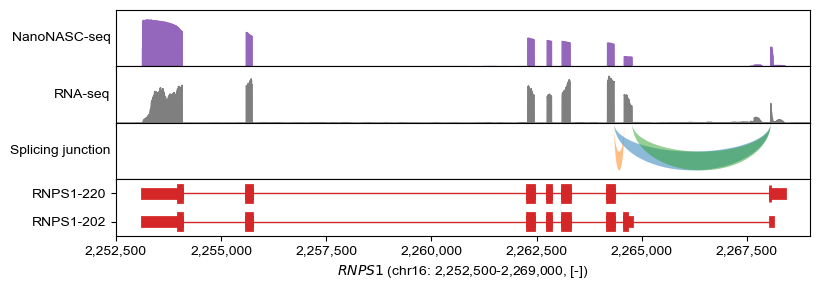

In [6]:
# RNPS1
gname = "RNPS1"
tids = ["ENST00000566458.5", "ENST00000320225.10"]
ts = [transcripts[tid] for tid in tids]
print(min([t.start for t in ts]), max([t.end for t in ts]))
start, end = 2252500, 2269000
step = 2500
print(start, end, step)
junctions = [
    [2264331, 2268054],
    [2264331, 2264572],
    [2264760, 2268054]
]
plot_tracks(ts, start, end, step, junctions, figsize=(8.3, 3), outfile="figures/gene_model.%s.pdf" % gname)

76048050 76067508
76047500 76068800 5000


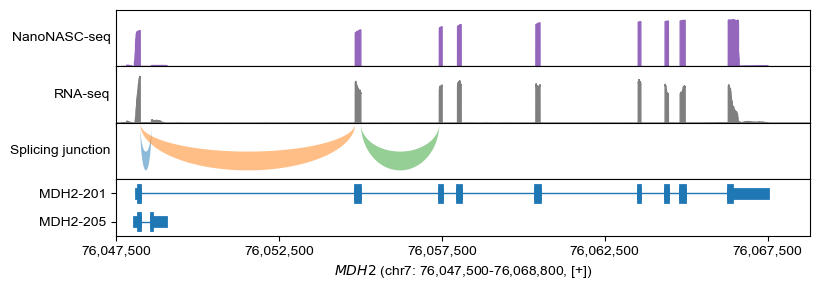

In [7]:
# MDH2
gname = "MDH2"
tids = ["ENST00000315758.10", "ENST00000461263.2"]
ts = [transcripts[tid] for tid in tids]
print(min([t.start for t in ts]), max([t.end for t in ts]))
start, end = 76047500, 76068800
step = 5000
print(start, end, step)
junctions = [
    [76048226, 76048575],
    [76048226, 76054829],
    [76054998, 76057409]
]
plot_tracks(ts, start, end, step, junctions, figsize=(8.3, 3), outfile="figures/gene_model.%s.pdf" % gname)

# Decay curve of intron (RNA-seq)

In [8]:
dat = pd.read_csv("../../3_RNAseq_ActD/reports/halflife_of_introns.tsv", sep="\t")
dat.index = ["%s:%s-%s" % (chrom, start, end) for chrom, start, end in dat[["Chrom", "Start", "End"]].values]

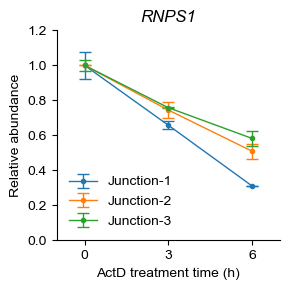

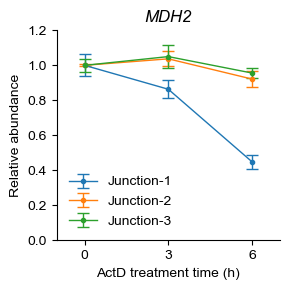

In [10]:
def plot_relative_abundance(gname, chrom, strand, introns, outfile=None):
    samples = ["0h-1", "0h-2", "3h-1", "3h-2", "6h-1", "6h-2"]
    tmp = dat[dat['Strand'] == strand]
    d = tmp.loc[["%s:%s-%s" % (chrom, start, end) for start, end in introns]]
    d = d[["Abundance.%s" % s for s in samples]]
    labels = ["Junction-%d" % (i + 1) for i in range(len(d))] # MDH2
    colors = ["C0", "C1", "C2", "C3"]
    xs = [0, 0, 3, 3, 6, 6]
    plt.figure(figsize=(3, 3))
    plt.title(gname, style="italic")
    for i in range(len(d)):
        m = d.values[i].reshape(3, -1)
        ys1 = np.mean(m, axis=1)
        yerr1 = np.std(m, axis=1)
        xs1 = [0, 3, 6]
        plt.errorbar(xs1, ys1, yerr=yerr1, marker=".", label=labels[i], capsize=4, capthick=1, lw=1)
    # plt.text(0, 0.2, "$\it{%s}$" % gene_name)    
    plt.ylim(0, 1.2)
    plt.xlabel("ActD treatment time (h)")
    plt.ylabel("Relative abundance")
    plt.xticks([0, 3, 6])
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.legend(frameon=False)
    plt.xlim(-1, 7)
    plt.tight_layout()
    plt.savefig("figures/validation_of_decay_by_ngs.%s.pdf" % gname)
    plt.show()
    plt.close()

plot_relative_abundance("RNPS1", "chr16", "-", [(2264331, 2268054), (2264331, 2264572), (2264760, 2268054)])
plot_relative_abundance("MDH2", "chr7", "+", [(76048226, 76048575), (76048226, 76054829), (76054998, 76057409)])